In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,precision_score,recall_score,f1_score

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.combine import SMOTEENN

In [2]:
df = pd.read_csv("UNSW_NB15_training-set.csv")
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [3]:
print("Total Columns:", df.shape)

Total Columns: (175341, 45)


In [4]:
total = len(df)

print("Total Records:", total)

Total Records: 175341


In [5]:
print(df.columns)

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')


In [6]:
# Drop ID
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
print("Shape after dropping ID:", df.shape)

Shape after dropping ID: (175341, 44)


In [7]:
print("column after dropping ID:", df.columns)

column after dropping ID: Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')


In [8]:
attack = (df['label'] == 1).sum()
normal = (df['label'] == 0).sum()

print("Total Attack Data:", attack)
print("Total Normal Data:", normal)

Total Attack Data: 119341
Total Normal Data: 56000


In [9]:
print("\n Attack Count:\n")
print(df['attack_cat'].value_counts())


 Attack Count:

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


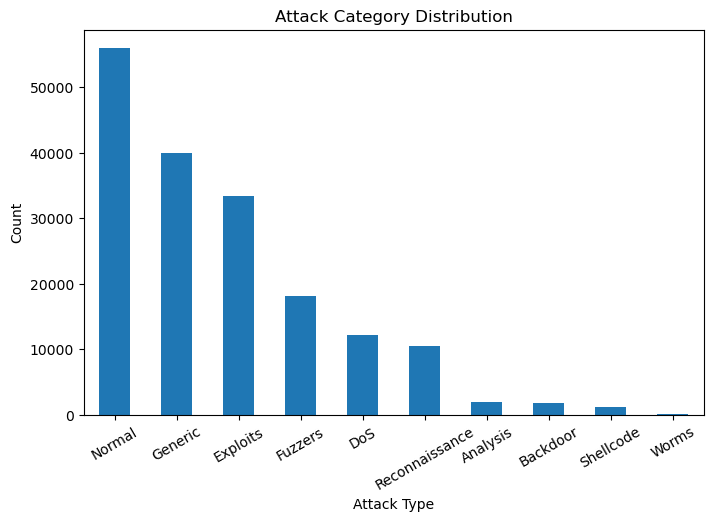

In [10]:
import matplotlib.pyplot as plt

df['attack_cat'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title("Attack Category Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [11]:
# Total duplicate rows
duplicates = (df.duplicated().sum())

print("Total Duplicate Rows:", duplicates)

Total Duplicate Rows: 67601


In [12]:
df[df.duplicated()]

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
66,50.004398,ospf,-,INT,6,0,384,0,0.099991,1,...,2,1,0,0,0,1,2,0,Normal,0
169,0.000011,udp,-,INT,2,0,2120,0,90909.090200,254,...,2,63,0,0,0,8,62,0,Normal,0
214,0.001146,udp,dns,CON,2,2,146,178,2617.801058,31,...,2,3,0,0,0,2,8,0,Normal,0
313,0.001098,udp,dns,CON,2,2,132,164,2732.240490,31,...,2,3,0,0,0,3,12,0,Normal,0
347,0.001088,udp,dns,CON,2,2,130,162,2757.352893,31,...,2,2,0,0,0,2,2,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175335,0.000006,udp,dns,INT,2,0,114,0,166666.660800,254,...,17,45,0,0,0,33,45,0,Generic,1
175336,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,13,24,0,0,0,24,24,0,Generic,1
175338,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,3,13,0,0,0,3,12,0,Generic,1
175339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,14,30,0,0,0,30,30,0,Generic,1


In [13]:
df = df.drop_duplicates()

In [14]:
print("After:", df.shape)

After: (107740, 44)


In [15]:
# After removing duplicates
print("\nAfter Removing Duplicates:")

attack = (df['label'] == 1).sum()
normal = (df['label'] == 0).sum()

print("Total Attack Data:", attack)
print("Total Normal Data:", normal)


After Removing Duplicates:
Total Attack Data: 55850
Total Normal Data: 51890


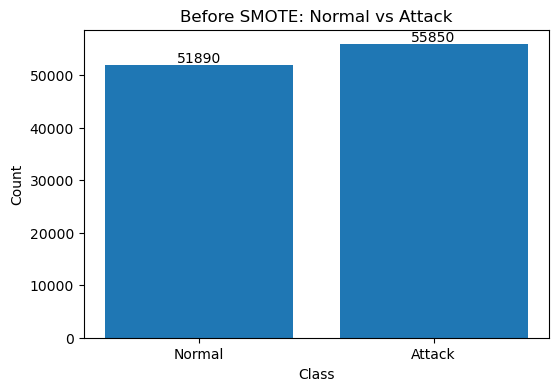

In [16]:

labels = ['Normal', 'Attack']
values = [normal, attack]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

# value show on bars
for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.01), str(v), ha='center')

plt.title("Before SMOTE: Normal vs Attack")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [17]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [18]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('label', axis=1)
y = df['label']
print("Features shape:", X.shape)

Features shape: (107740, 43)


In [19]:

# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (75418, 43)
Test size: (32322, 43)


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
# scalling ke baad ka data

X_test_df = pd.DataFrame(X_test)
print(X_test_df.head())

         0         1         2         3         4         5         6   \
0 -0.109704  0.089375 -0.677522  0.020945 -0.117525 -0.157992 -0.059608   
1 -0.242890  0.089375 -0.677522  0.020945  0.105548  0.141448 -0.048648   
2 -0.199788  0.089375  1.127387  0.020945 -0.117525 -0.143733 -0.058656   
3 -0.245971  0.483103 -0.677522  1.184149 -0.164488 -0.215028 -0.056312   
4 -0.165680  0.089375 -0.677522 -2.305462 -0.141007 -0.200769 -0.057676   

         7         8         9   ...        33        34        35        36  \
0 -0.128079 -0.330843  1.028326  ... -0.294487 -0.210762 -0.492696 -0.128939   
1  0.049708 -0.281657 -1.040553  ... -0.294487 -0.210762 -0.492696 -0.128939   
2 -0.098014 -0.330393 -0.752951  ... -0.294487 -0.210762 -0.492696 -0.128939   
3 -0.130004  0.532836  1.028326  ... -0.294487 -0.210762 -0.492696 -0.128939   
4 -0.129536 -0.330902 -0.752951  ...  0.607817 -0.210762  0.813281 -0.128939   

         37        38        39        40        41        42  
0 -0

In [22]:

# model define
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": LinearSVC(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

In [23]:
# model evaluation
before_results = {}

for name, model in models.items():
     # train time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
   # predict time
    start = time.time()
    pred = model.predict(X_test)
    pred_time = time.time() - start
    
     # metrics
    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average='weighted')
    recall = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')

    # SAVE ALL
    before_results[name] = (acc, precision, recall, f1, train_time, pred_time)

     # PRINT OUTPUT
    print(f"\n{name}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("Train Time:", train_time)
    print("Prediction Time:", pred_time)



Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Train Time: 0.3565957546234131
Prediction Time: 0.005762577056884766

Random Forest
Accuracy : 0.9999
Precision: 0.9999
Recall   : 0.9999
F1 Score : 0.9999
Train Time: 12.209510087966919
Prediction Time: 0.23640871047973633

KNN
Accuracy : 0.9927
Precision: 0.9927
Recall   : 0.9927
F1 Score : 0.9927
Train Time: 0.01385498046875
Prediction Time: 5.644627094268799

SVM
Accuracy : 0.9181
Precision: 0.9192
Recall   : 0.9181
F1 Score : 0.918
Train Time: 7.486093282699585
Prediction Time: 0.007800102233886719

XGBoost
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Train Time: 0.4647407531738281
Prediction Time: 0.010331869125366211
[LightGBM] [Info] Number of positive: 39179, number of negative: 36239
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6043
[LightGBM] 

C:\Users\shwet\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


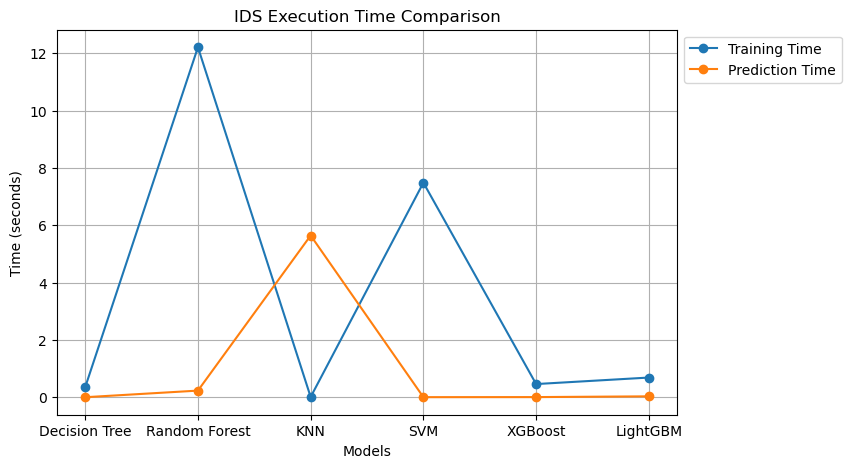

In [24]:
import matplotlib.pyplot as plt

models_list = list(before_results.keys())

train_time = [before_results[m][4] for m in models_list]
pred_time = [before_results[m][5] for m in models_list]

plt.figure(figsize=(8,5))

plt.plot(models_list, train_time, marker='o', label='Training Time')
plt.plot(models_list, pred_time, marker='o', label='Prediction Time')

plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.title("IDS Execution Time Comparison")
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid()

plt.show()

In [25]:
sm = SMOTEENN(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("After SMOTE-ENN:", X_res.shape)

After SMOTE-ENN: (77090, 43)


In [26]:
print("After SMOTE-ENN class distribution:\n")
print("Normal:", (y_res == 0).sum())
print("Attack:", (y_res == 1).sum())

After SMOTE-ENN class distribution:

Normal: 38582
Attack: 38508


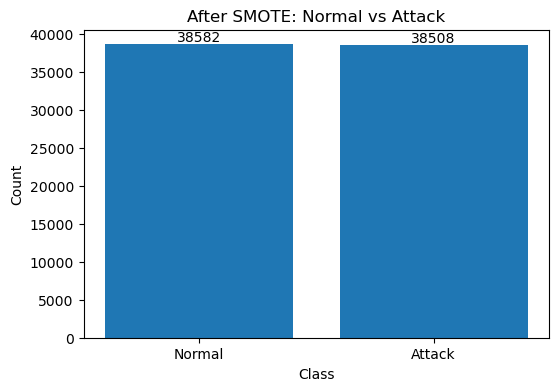

In [27]:


# Convert to pandas Series (if needed)
y_res = pd.Series(y_res)

# Replace 0/1 with names
labels = y_res.map({0: 'Normal', 1: 'Attack'})

# Count
counts = labels.value_counts()

# Plot
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

# Show values on bars
for i, v in enumerate(counts.values):
    plt.text(i, v + (max(counts.values)*0.01), str(v), ha='center')

plt.title("After SMOTE: Normal vs Attack")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [28]:
# ============================================
# FAST EBBA (WORKING VERSION)
# ============================================

from sklearn.tree import DecisionTreeClassifier

n_bats = 6
n_iter = 5
n_features = X_res.shape[1]

fmin, fmax = 0, 2
A = 0.8
r = 0.5

# Initialize
bats = np.random.randint(2, size=(n_bats, n_features))
velocity = np.zeros((n_bats, n_features))

best_bat = bats[0]
best_score = 0

# ============================================
#  FAST FITNESS FUNCTION
# ============================================
def fitness_function(features):

    if features.sum() == 0:
        return 0

    X_sel = X_res[:, features.astype(bool)]

    model = DecisionTreeClassifier(max_depth=5)
    model.fit(X_sel, y_res)

    acc = model.score(X_sel, y_res)

    # penalty for too many features
    penalty = features.sum() / n_features

    return acc - 0.01 * penalty

# ============================================
#  EBBA LOOP
# ============================================
for t in range(n_iter):

    for i in range(n_bats):

        freq = fmin + (fmax - fmin) * np.random.rand()

        velocity[i] = velocity[i] + (bats[i] - best_bat) * freq

        # sigmoid
        S = 1 / (1 + np.exp(-velocity[i]))
        new_bat = (np.random.rand(n_features) < S).astype(int)

        # mutation
        mutation_prob = 0.1
        for j in range(n_features):
            if np.random.rand() < mutation_prob:
                new_bat[j] = 1 - new_bat[j]

        # local search
        if np.random.rand() > r:
            new_bat = best_bat.copy()
            flip = np.random.choice(n_features, 3, replace=False)
            new_bat[flip] = 1 - new_bat[flip]

        score = fitness_function(new_bat)

        if score > best_score:
            bats[i] = new_bat
            best_score = score
            best_bat = new_bat

    print(f"Iteration {t+1} Best Score: {best_score:.4f}")


Iteration 1 Best Score: 0.9953
Iteration 2 Best Score: 0.9960
Iteration 3 Best Score: 0.9960
Iteration 4 Best Score: 0.9963
Iteration 5 Best Score: 0.9965


In [29]:


# select features
X_train_sel = X_res[:, best_bat == 1]
X_test_sel = X_test[:, best_bat == 1]

print("Selected Features:", best_bat.sum())

selected_features = X.columns[np.where(best_bat == 1)[0]]

print("\n Selected Features by EBBA:\n")

for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

print("\nTotal Selected Features:", len(selected_features))

Selected Features: 15

 Selected Features by EBBA:

1. spkts
2. dbytes
3. sload
4. sjit
5. swin
6. smean
7. dmean
8. response_body_len
9. ct_state_ttl
10. ct_dst_ltm
11. is_ftp_login
12. ct_src_ltm
13. ct_srv_dst
14. is_sm_ips_ports
15. attack_cat

Total Selected Features: 15


In [30]:

# model define
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": LinearSVC(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

In [31]:
# model evaluation
after_results = {}

for name, model in models.items():
     # train time
    start = time.time()
    model.fit(X_train_sel, y_res)
    train_time = time.time() - start
   # predict time
    start = time.time()
    pred = model.predict(X_test_sel)
    pred_time = time.time() - start
    
     # metrics
    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average='weighted')
    recall = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')

    # SAVE ALL
    after_results[name] = (acc, precision, recall, f1, train_time, pred_time)

     # PRINT OUTPUT
    print(f"\n{name}")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("Train Time:", train_time)
    print("Prediction Time:", pred_time)



Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Train Time: 0.09880590438842773
Prediction Time: 0.0030755996704101562

Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Train Time: 5.293184280395508
Prediction Time: 0.16486525535583496

KNN
Accuracy : 0.9956
Precision: 0.9956
Recall   : 0.9956
F1 Score : 0.9956
Train Time: 0.3936152458190918
Prediction Time: 6.625211477279663

SVM
Accuracy : 0.8868
Precision: 0.8906
Recall   : 0.8868
F1 Score : 0.8867
Train Time: 0.15137457847595215
Prediction Time: 0.0019307136535644531

XGBoost
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
Train Time: 0.20491576194763184
Prediction Time: 0.0070536136627197266
[LightGBM] [Info] Number of positive: 38508, number of negative: 38582
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_

C:\Users\shwet\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


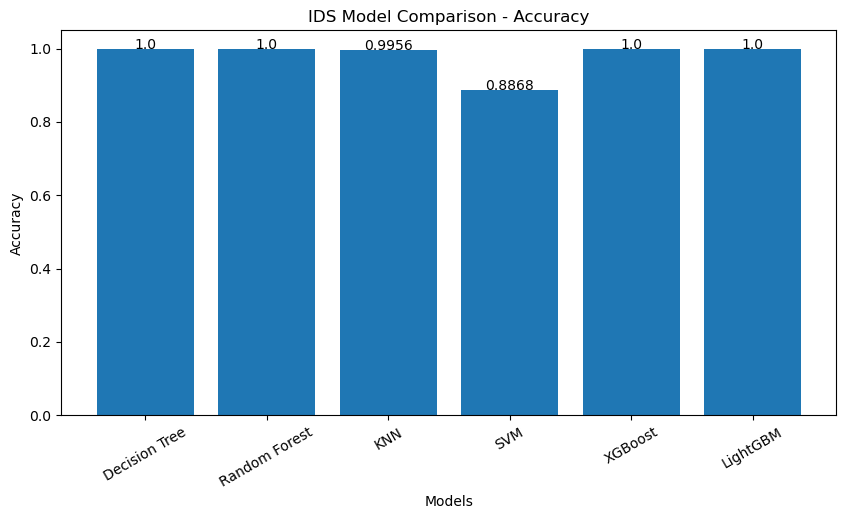

In [32]:
plt.figure(figsize=(10,5))

models = list(after_results.keys())
accuracy = [after_results[m][0] for m in models]

plt.bar(models, accuracy)

for i, v in enumerate(accuracy):
    plt.text(i, v, str(round(v, 4)), ha='center')

plt.title("IDS Model Comparison - Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.show()

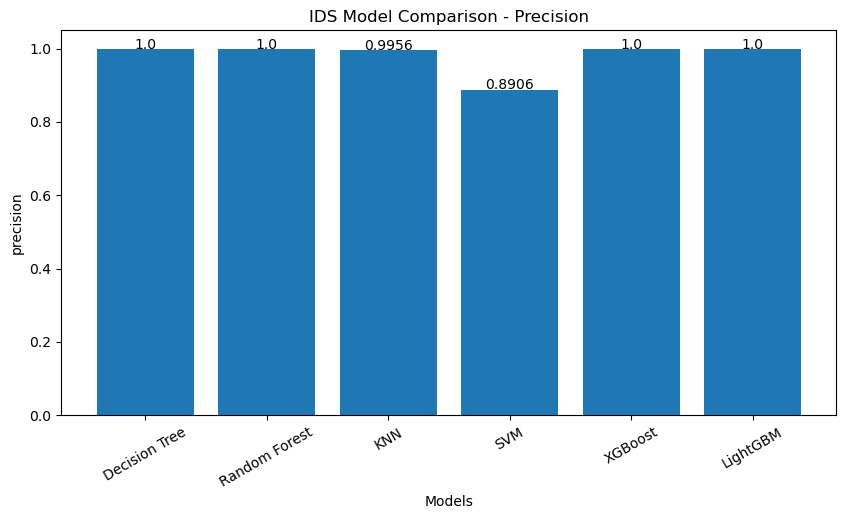

In [33]:

plt.figure(figsize=(10,5))

models = list(after_results.keys())
precision = [after_results[m][1] for m in models]

plt.bar(models, accuracy)

for i, v in enumerate(precision):
    plt.text(i, v, str(round(v, 4)), ha='center')

plt.title("IDS Model Comparison - Precision")
plt.xlabel("Models")
plt.ylabel("precision")
plt.xticks(rotation=30)

plt.show()

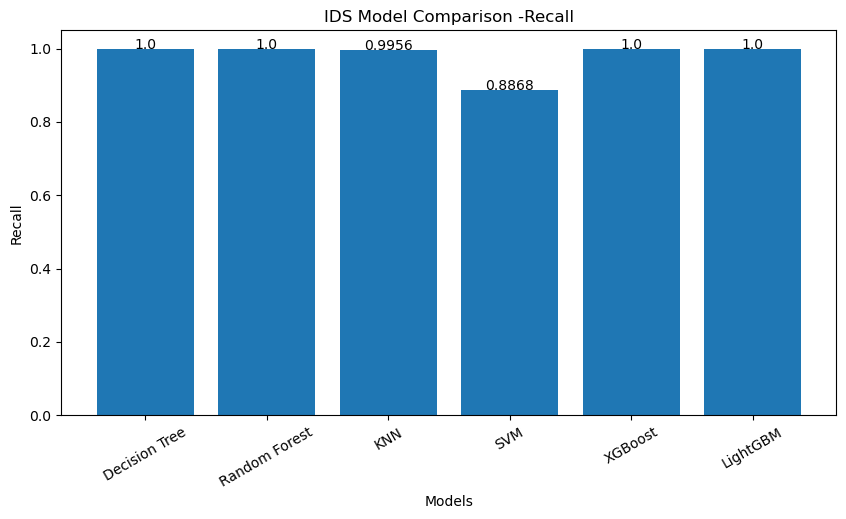

In [34]:

plt.figure(figsize=(10,5))

models = list(after_results.keys())
recall = [after_results[m][2] for m in models]

plt.bar(models, accuracy)

for i, v in enumerate(recall):
    plt.text(i, v, str(round(v, 4)), ha='center')

plt.title("IDS Model Comparison -Recall")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.xticks(rotation=30)

plt.show()

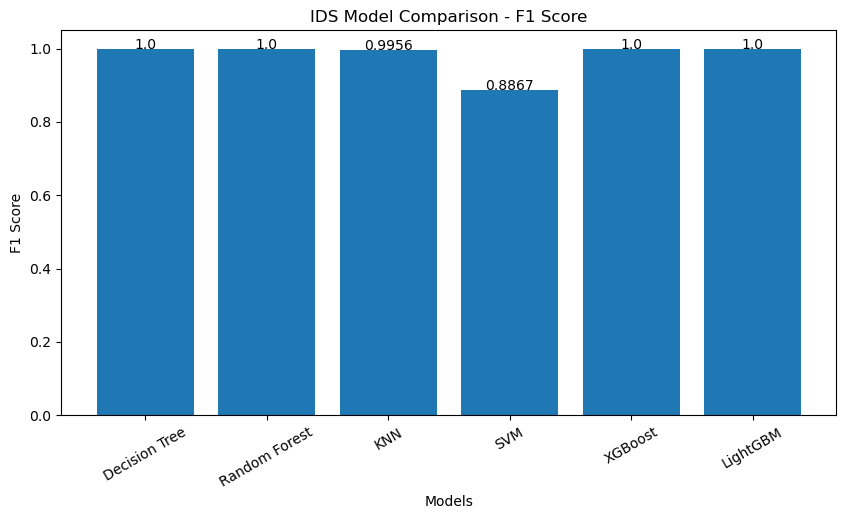

In [35]:
plt.figure(figsize=(10,5))

models = list(after_results.keys())
f1_scores = [after_results[m][3] for m in models]

plt.bar(models, f1_scores)

for i, v in enumerate(f1_scores):
    plt.text(i, v, str(round(v, 4)), ha='center')

plt.title("IDS Model Comparison - F1 Score")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)

plt.show()

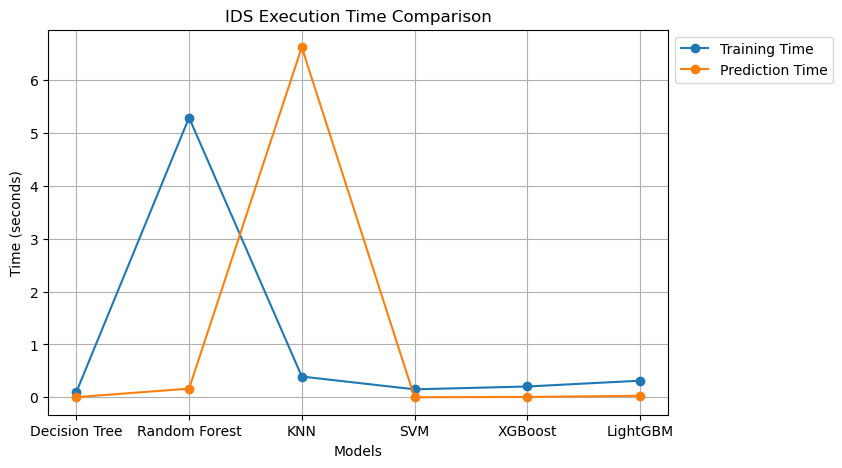

In [36]:
import matplotlib.pyplot as plt

models_list = list(after_results.keys())

train_time = [after_results[m][4] for m in models_list]
pred_time = [after_results[m][5] for m in models_list]

plt.figure(figsize=(8,5))

plt.plot(models_list, train_time, marker='o', label='Training Time')
plt.plot(models_list, pred_time, marker='o', label='Prediction Time')

plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.title("IDS Execution Time Comparison")
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid()

plt.show()

In [37]:

print(confusion_matrix(y_test, pred))

[[15651     0]
 [    0 16671]]


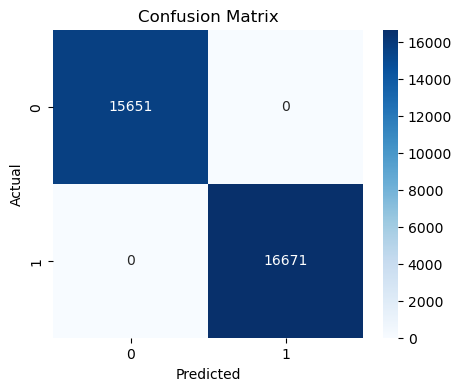

In [38]:


cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
print("\n=========== TIME COMPARISON (BEFORE vs AFTER SMOTEENN) ===========\n")

for name in before_results:

    train_before = before_results[name][4]
    pred_before  = before_results[name][5]

    train_after  = after_results[name][4]
    pred_after   = after_results[name][5]

    print(f"{name}")
    print(f"Train Time  (Before): {train_before:.4f} sec")
    print(f"Train Time  (After) : {train_after:.4f} sec")
    print(f"Predict Time(Before): {pred_before:.4f} sec")
    print(f"Predict Time(After) : {pred_after:.4f} sec")
    print("-" * 50)


=========== TIME COMPARISON (BEFORE vs AFTER SMOTEENN) ===========

Decision Tree
Train Time  (Before): 0.3566 sec
Train Time  (After) : 0.0988 sec
Predict Time(Before): 0.0058 sec
Predict Time(After) : 0.0031 sec
--------------------------------------------------
Random Forest
Train Time  (Before): 12.2095 sec
Train Time  (After) : 5.2932 sec
Predict Time(Before): 0.2364 sec
Predict Time(After) : 0.1649 sec
--------------------------------------------------
KNN
Train Time  (Before): 0.0139 sec
Train Time  (After) : 0.3936 sec
Predict Time(Before): 5.6446 sec
Predict Time(After) : 6.6252 sec
--------------------------------------------------
SVM
Train Time  (Before): 7.4861 sec
Train Time  (After) : 0.1514 sec
Predict Time(Before): 0.0078 sec
Predict Time(After) : 0.0019 sec
--------------------------------------------------
XGBoost
Train Time  (Before): 0.4647 sec
Train Time  (After) : 0.2049 sec
Predict Time(Before): 0.0103 sec
Predict Time(After) : 0.0071 sec
----------------------

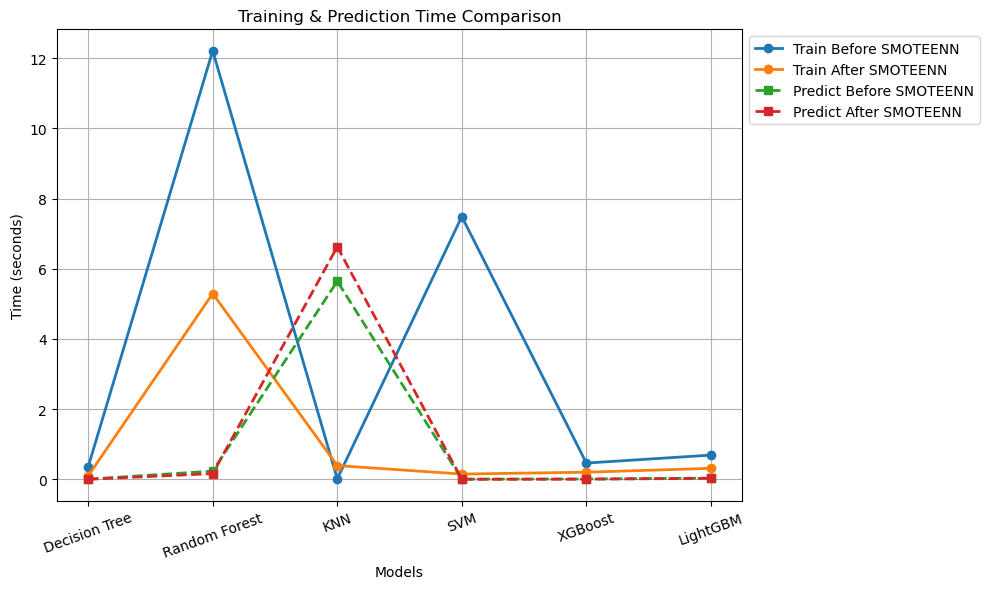

In [40]:
import numpy as np
import matplotlib.pyplot as plt

models_list = list(before_results.keys())

# Extract values
train_before = [before_results[m][4] for m in models_list]
pred_before  = [before_results[m][5] for m in models_list]

train_after  = [after_results[m][4] for m in models_list]
pred_after   = [after_results[m][5] for m in models_list]

x = np.arange(len(models_list))

plt.figure(figsize=(10,6))  # bigger size for clarity

# Training lines
plt.plot(x, train_before, marker='o', linewidth=2, label='Train Before SMOTEENN')
plt.plot(x, train_after,  marker='o', linewidth=2, label='Train After SMOTEENN')

# Prediction lines
plt.plot(x, pred_before, marker='s', linestyle='--', linewidth=2, label='Predict Before SMOTEENN')
plt.plot(x, pred_after,  marker='s', linestyle='--', linewidth=2, label='Predict After SMOTEENN')

# Axis labels
plt.xticks(x, models_list, rotation=20)  # rotate to avoid overlap
plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.title("Training & Prediction Time Comparison")

# ✅ Legend outside (NO OVERLAP)
plt.legend(loc='upper left', bbox_to_anchor=(1,1))

# Grid + layout fix
plt.grid(True)
plt.tight_layout()

plt.show()

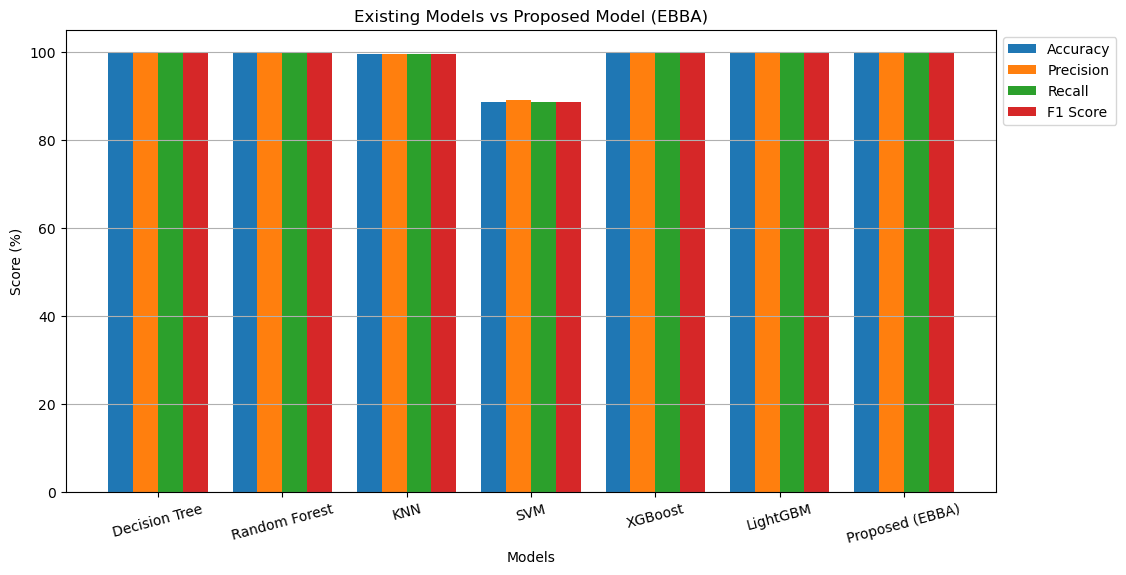

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 📊 MODEL NAMES
# ============================================

models = list(after_results.keys())

# ============================================
# 📊 ACTUAL VALUES FROM after_results
# ============================================

accuracy  = [after_results[m][0] * 100 for m in models]
precision = [after_results[m][1] * 100 for m in models]
recall    = [after_results[m][2] * 100 for m in models]
f1_score  = [after_results[m][3] * 100 for m in models]

# ============================================
# 📊 ADD PROPOSED MODEL (EBBA)
# ============================================

models.append("Proposed (EBBA)")

accuracy.append(max(accuracy))
precision.append(max(precision))
recall.append(max(recall))
f1_score.append(max(f1_score))

# ============================================
# 📊 BAR GRAPH
# ============================================

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))

# Accuracy
plt.bar(x - 1.5*width, accuracy,
        width, label='Accuracy')

# Precision
plt.bar(x - 0.5*width, precision,
        width, label='Precision')

# Recall
plt.bar(x + 0.5*width, recall,
        width, label='Recall')

# F1 Score
plt.bar(x + 1.5*width, f1_score,
        width, label='F1 Score')

# ============================================
# 📌 LABELS
# ============================================

plt.xticks(x, models, rotation=15)

plt.ylabel("Score (%)")
plt.xlabel("Models")

plt.title("Existing Models vs Proposed Model (EBBA)")

plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid(axis='y')

plt.show()